In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/clean_price_data.csv", parse_dates=["timestamp"])
df = df.set_index("timestamp")

In [2]:
df["lag_1"] = df["price"].shift(1)
df["lag_24"] = df["price"].shift(24)
df["lag_168"] = df["price"].shift(168)

df.head()

,price,lag_1,lag_24,lag_168
timestamp,,,,
2023-01-01 00:00:00,-5.17,NaN,NaN,NaN
2023-01-01 01:00:00,-1.07,-5.17,NaN,NaN
2023-01-01 02:00:00,-1.47,-1.07,NaN,NaN
2023-01-01 03:00:00,-5.08,-1.47,NaN,NaN
2023-01-01 04:00:00,-4.49,-5.08,NaN,NaN


In [4]:
df = df.dropna()
df.head()


,price,lag_1,lag_24,lag_168
timestamp,,,,
2023-01-08 00:00:00,10.93,38.25,97.15,-5.17
2023-01-08 01:00:00,9.07,10.93,98.43,-1.07
2023-01-08 02:00:00,9.10,9.07,96.05,-1.47
2023-01-08 03:00:00,4.16,9.10,87.97,-5.08
2023-01-08 04:00:00,5.58,4.16,82.99,-4.49


In [5]:
train = df[: "2025-12-31"]
test = df["2026-01-01":]


In [10]:
test["pred_lag1"] = test["lag_1"]

test["pred_lag24"] = test["lag_24"]

test["pred_lag168"] = test["lag_168"]

In [11]:
from sklearn.metrics import mean_absolute_error

mae_lag1 = mean_absolute_error(test["price"], test["pred_lag1"])
mae_lag24 = mean_absolute_error(test["price"], test["pred_lag24"])
mae_lag168 = mean_absolute_error(test["price"], test["pred_lag168"])

print("MAE lag1:", mae_lag1)
print("MAE lag24:", mae_lag24)
print("MAE lag168:", mae_lag168)

MAE lag1: 7.604052083333333
MAE lag24: 22.043645833333336
MAE lag168: 25.697406250000004


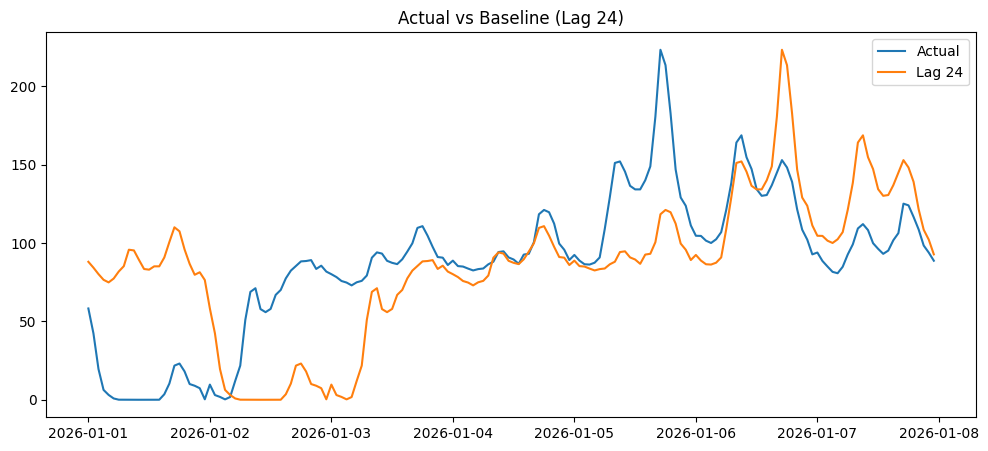

In [15]:
import matplotlib.pyplot as plt

sample = test["2026-01-01":"2026-01-07"]

plt.figure(figsize=(12,5))
plt.plot(sample.index, sample["price"], label="Actual")
plt.plot(sample.index, sample["pred_lag24"], label="Lag 24")
plt.legend()
plt.title("Actual vs Baseline (Lag 24)")
plt.show()